TF-IDF shape: (769, 7042)
SVD shape: (769, 100)
Explained variance: 0.34251775319854655


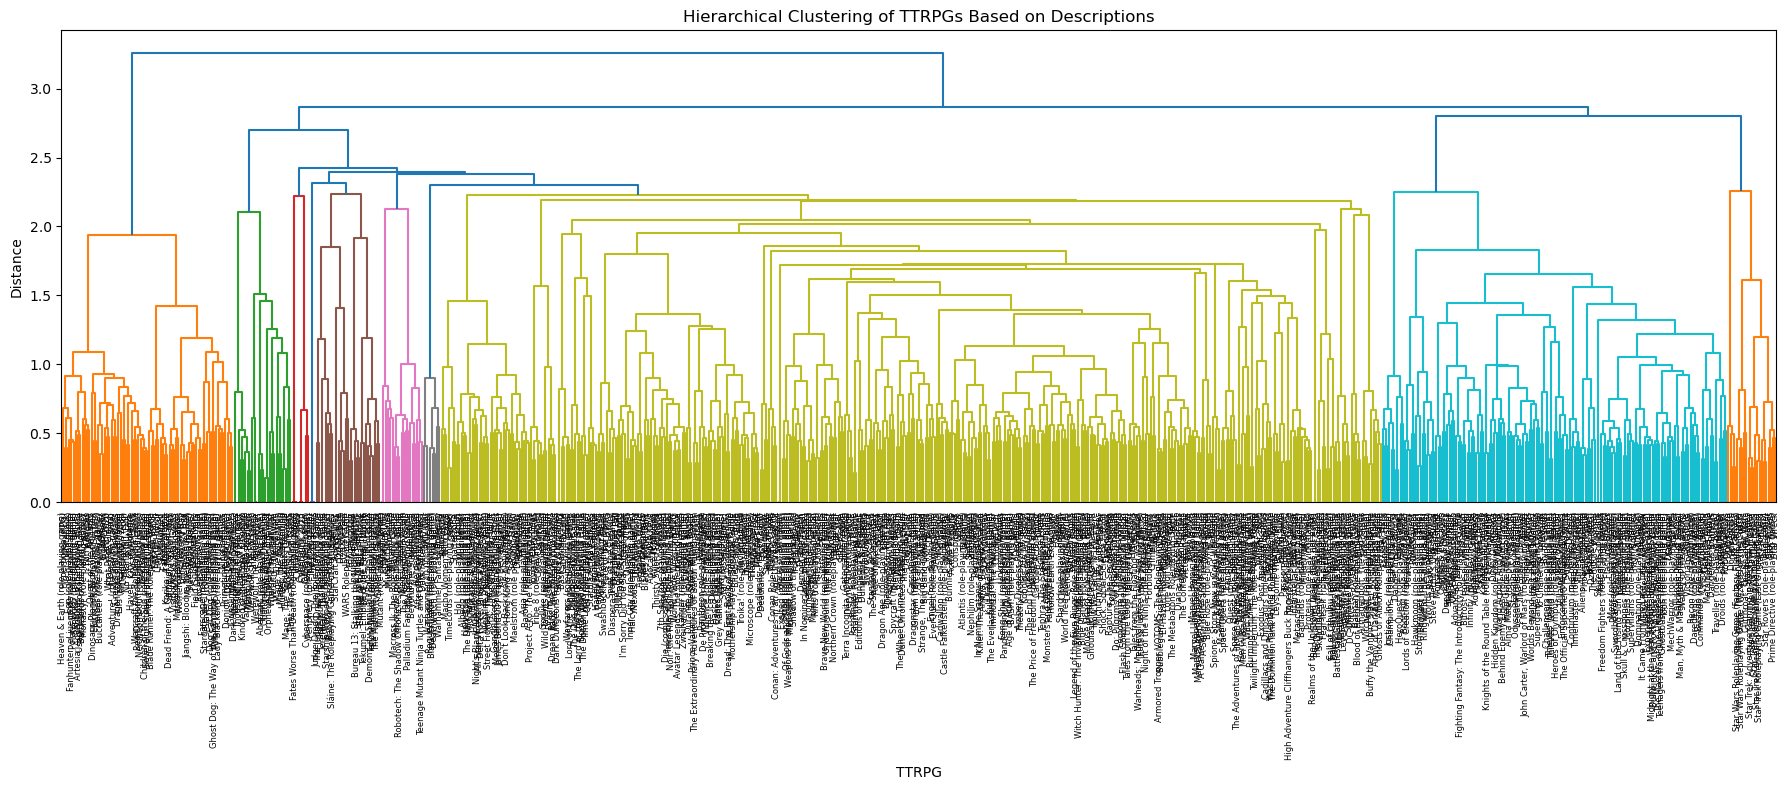

,game,publisher,system,release_year,setting,cluster
0,13th Age,Pelgrane Press,D20 System,2013,High fantasy,3
1,The 23rd Letter,Crucible Design,NaN,1996,NaN,3
2,2300 AD,Game Designers' Workshop,NaN,1989,Hard science fiction,4
3,3D&T,Editora Talismã (formerly Trama Editorial),NaN,1994,NaN,3
4,7th Sea (role-playing game),Alderac Entertainment Group,D20 System,"1999, 2016",Pirate,3


In [3]:
# HIERARCHICAL CLUSTERING FOR TTRPG DESCRIPTIONS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 1. Load dataset
# Your notebook is in working-notebooks/brit
# The CSV is in working-notebooks/q
df = pd.read_csv("../q/test_scrape.csv")

# 2. Clean dataset
df = df.dropna(subset=["description"]).copy()
df["description"] = df["description"].astype(str)
df = df[df["description"].str.strip() != ""].copy()

# Optional: remove duplicate games
df = df.drop_duplicates(subset=["game"]).reset_index(drop=True)

X = df["description"]
labels = df["game"]

# 3. TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r"\w+",
    stop_words=stopwords.words("english"),
    lowercase=True,
    min_df=5
)

X_tfidf = tfidf_vectorizer.fit_transform(X)

print("TF-IDF shape:", X_tfidf.shape)

# 4. Reduce dimensions using SVD
# Use fewer components so hierarchical clustering is easier and faster.
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

semantic_vectors = pd.DataFrame(
    X_svd,
    columns=[f"SV {i+1}" for i in range(X_svd.shape[1])]
)

print("SVD shape:", semantic_vectors.shape)
print("Explained variance:", svd.explained_variance_ratio_.sum())

# 5. Hierarchical clustering
Z = linkage(semantic_vectors, method="ward")

# 6. Plot dendrogram
plt.figure(figsize=(18, 8))

dendrogram(
    Z,
    labels=labels.values,
    leaf_rotation=90,
    leaf_font_size=6
)

plt.title("Hierarchical Clustering of TTRPGs Based on Descriptions")
plt.xlabel("TTRPG")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# 7. Assign cluster labels
# Change this after looking at the dendrogram.
n_clusters = 5

df["cluster"] = fcluster(
    Z,
    t=n_clusters,
    criterion="maxclust"
)

df[["game", "publisher", "system", "release_year", "setting", "cluster"]].head()

In [4]:
# CHECK GAMES INSIDE EACH CLUSTER

for cluster_id in sorted(df["cluster"].unique()):
    print("\n====================")
    print(f"Cluster {cluster_id}")
    print("====================")
    
    sample_games = df[df["cluster"] == cluster_id][
        ["game", "publisher", "system", "release_year", "setting"]
    ].head(15)
    
    print(sample_games.to_string(index=False))


Cluster 1
                                   game                              publisher           system                            release_year                                               setting
         Adventure! (role-playing game)                         Tori Bergquist              NaN                                    1985                                                   NaN
                       Armageddon: 2089                    Mongoose Publishing              NaN                                    2003                                                   NaN
 Artesia: Adventures in the Known World                  Archaia Entertainment           Fuzion                                    2005                                                   NaN
        Battlelords of the 23rd Century                             SSDC, Inc.              NaN 1990,\n1991,\n1992,\n1993,\n2000,\n2019                                                   NaN
     Blade Runner: The Roleplaying Game

In [ ]:
# FIND TOP WORDS PER CLUSTER

tfidf_words = tfidf_vectorizer.get_feature_names_out()

df_tfidf_dense = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_words
)

df_tfidf_dense["cluster"] = df["cluster"].values

for cluster_id in sorted(df["cluster"].unique()):
    cluster_words = (
        df_tfidf_dense[df_tfidf_dense["cluster"] == cluster_id]
        .drop(columns="cluster")
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )
    
    print(f"\nTop words for Cluster {cluster_id}:")
    print(cluster_words)

In [5]:
# COMPARE DIFFERENT NUMBERS OF CLUSTERS

cluster_results = []

for k in range(2, 11):
    cluster_labels = fcluster(Z, t=k, criterion="maxclust")
    
    sil_score = silhouette_score(semantic_vectors, cluster_labels)
    db_score = davies_bouldin_score(semantic_vectors, cluster_labels)
    
    cluster_results.append({
        "k": k,
        "silhouette_score": sil_score,
        "davies_bouldin_score": db_score
    })

cluster_results_df = pd.DataFrame(cluster_results)
cluster_results_df

,k,silhouette_score,davies_bouldin_score
0,2,-0.000880,3.651153
1,3,0.001921,5.274049
2,4,0.000314,4.381083
3,5,0.006845,4.099946
4,6,0.012218,3.708172
5,7,0.017599,3.686201
6,8,0.022492,3.535346
7,9,0.027523,3.191753
8,10,0.032489,3.019605
